# Seasonal Agriculture Performance Analysis

**VOIS AICTE Batch 2026-27 — Major Project**

**Student:** Vishnu Koukuntla
**College:** N.K. Orchid College of Engineering
**AICTE STU ID:** STU6a6a2e387406a1785343544

---

## 1. Introduction to Dataset

The dataset represents agricultural activities carried out across different seasons, geographical
areas and farming conditions in India. It contains information on farming practices, environmental
conditions, crop production, resource usage and economic performance for **4,000 farm records**
spanning **8 states**, **8 crops** and **3 cropping seasons** — *Kharif*, *Rabi* and *Zaid*.

## 2. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming
practices, resource availability and market conditions. As a result, agricultural performance may
differ from one season to another. Raw agricultural data does not, by itself, explain how performance
changes across seasons or what patterns exist within different seasonal conditions.

**This notebook investigates seasonal differences in agricultural performance** by identifying
meaningful patterns, trends, relationships and variations within the dataset — and tests whether the
seasonal differences observed are statistically significant, not just visually different.

## 3. Objective

- Explore and clean the dataset
- Examine how yield, profit, cost, water efficiency and disease/pest risk vary across seasons
- Test statistical significance of seasonal differences (one-way ANOVA)
- Investigate relationships between environmental conditions and outcomes
- Compare performance across crops, irrigation methods and states
- Draw evidence-based conclusions and recommendations for seasonal agricultural planning


## 4. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#CCCCCC'
plt.rcParams['axes.linewidth'] = 0.8

# Theme colors (used consistently across all charts)
NAVY = "#2C3C43"
BLUE_DARK = "#2E83C3"
BLUE_LIGHT = "#5FCBEF"
TEAL = "#42D0A2"
GREEN = "#2E946B"
GRAY = "#8A9BA3"

SEASONS = ['Kharif', 'Rabi', 'Zaid']


## 5. Load the Dataset

The dataset is a CSV file with 4,000 rows covering farm-level records across states, crops and
seasons.

In [2]:
df = pd.read_csv('data/seasonal_agriculture_performance_dataset.csv')
print("Shape:", df.shape)
df.head()


Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [4]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF10001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,4000.0,NaN,NaN,NaN,7.888265,4.223764,0.5,4.26,7.895,11.65,15.0
Rainfall_mm,3952.0,NaN,NaN,NaN,601.152657,288.925025,80.0,370.2,582.0,834.95,1395.2
Avg_Temperature_C,4000.0,NaN,NaN,NaN,26.8189,3.81818,16.2,23.9,26.9,29.6,39.7
Humidity_pct,4000.0,NaN,NaN,NaN,63.2105,11.960834,25.0,54.775,63.0,71.9,95.0
Sunlight_Hours_Day,4000.0,NaN,NaN,NaN,7.32305,1.121186,3.5,6.6,7.3,8.1,11.0


## 6. Data Cleaning

Check for missing values and handle them before analysis.

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)
print(f"\nTotal missing cells: {missing.sum()} out of {df.shape[0]*df.shape[1]} ({missing.sum()/(df.shape[0]*df.shape[1])*100:.2f}%)")


Columns with missing values:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Total missing cells: 120 out of 112000 (0.11%)


In [6]:
# The missing values are a small fraction of the dataset and are concentrated in a few
# environmental columns (e.g. Rainfall_mm, Soil_Moisture_pct, Yield_Tonnes_Ha).
# We drop rows with missing values in columns that are central to this analysis, since the
# proportion missing is small enough that imputation is not required.
key_cols = ['Yield_Tonnes_Ha', 'Rainfall_mm', 'Soil_Moisture_pct']
before = len(df)
df = df.dropna(subset=[c for c in key_cols if c in df.columns]).reset_index(drop=True)
after = len(df)
print(f"Rows before cleaning: {before}, after cleaning: {after} ({before-after} rows dropped)")


Rows before cleaning: 4000, after cleaning: 3880 (120 rows dropped)


In [7]:
# Derived per-hectare economic metrics (useful for comparing farms of different sizes fairly)
df['Profit_per_Ha']  = df['Profit_INR']  / df['Farm_Area_Hectares']
df['Revenue_per_Ha'] = df['Revenue_INR'] / df['Farm_Area_Hectares']
df['Cost_per_Ha']    = df['Total_Cost_INR'] / df['Farm_Area_Hectares']
df[['Profit_per_Ha','Revenue_per_Ha','Cost_per_Ha']].describe().round(0)


,Profit_per_Ha,Revenue_per_Ha,Cost_per_Ha
count,3880.0,3880.0,3880.0
mean,13744.0,80386.0,66642.0
std,59094.0,58445.0,8841.0
min,-83127.0,4439.0,35807.0
25%,-25311.0,42407.0,60597.0
50%,852.0,67159.0,66619.0
75%,31343.0,96947.0,72727.0
max,356586.0,422794.0,97185.0


## 7. Exploratory Data Analysis — Dataset Composition

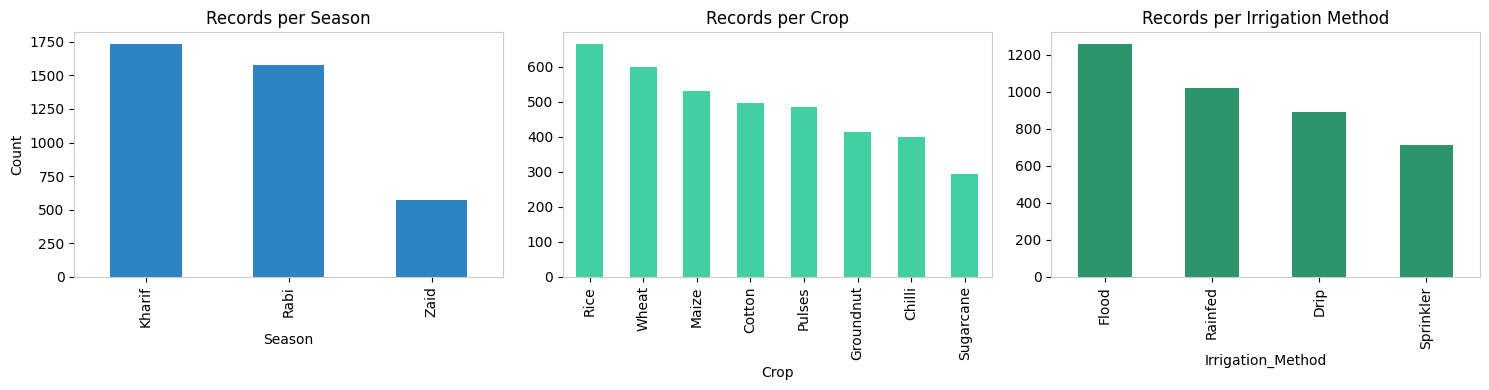

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df['Season'].value_counts().reindex(SEASONS).plot(kind='bar', ax=axes[0], color=BLUE_DARK)
axes[0].set_title('Records per Season'); axes[0].set_ylabel('Count')
df['Crop'].value_counts().plot(kind='bar', ax=axes[1], color=TEAL)
axes[1].set_title('Records per Crop')
df['Irrigation_Method'].value_counts().plot(kind='bar', ax=axes[2], color=GREEN)
axes[2].set_title('Records per Irrigation Method')
plt.tight_layout()
plt.show()


## 8. Seasonal Performance Summary

Average of the key metrics, grouped by season.

In [9]:
metrics = ['Yield_Tonnes_Ha','Production_Tonnes','Profit_INR','Revenue_INR','Total_Cost_INR',
           'Water_Used_m3','Water_Efficiency_t_per_1000m3','Fertilizer_kg_ha','Pesticide_Litre_ha',
           'Disease_Pest_Risk_pct','Rainfall_mm','Avg_Temperature_C','Humidity_pct','Soil_Moisture_pct']
season_summary = df.groupby('Season')[metrics].mean().reindex(SEASONS).round(2)
season_summary.T


Season,Kharif,Rabi,Zaid
Yield_Tonnes_Ha,5.67,4.98,4.64
Production_Tonnes,46.51,40.65,39.34
Profit_INR,181539.02,86222.09,-26635.69
Revenue_INR,712489.58,598348.82,518555.62
Total_Cost_INR,530950.56,512126.73,545191.30
Water_Used_m3,6053.39,5791.91,6481.22
Water_Efficiency_t_per_1000m3,5.93,5.14,4.44
Fertilizer_kg_ha,187.25,185.42,183.94
Pesticide_Litre_ha,5.08,5.02,5.15
Disease_Pest_Risk_pct,54.45,40.52,38.11


## 9. Is the Seasonal Difference Statistically Significant?

A visual difference in averages isn't proof of a real effect — it could be random noise. We run a
**one-way ANOVA** for each key metric across the three seasons. A p-value below 0.05 tells us the
seasonal grouping explains real variation in that metric, not chance.

In [10]:
print(f"{'Metric':35s} {'F-statistic':>12s} {'p-value':>14s}  Significant?")
print("-"*80)
for col in ['Yield_Tonnes_Ha','Profit_INR','Disease_Pest_Risk_pct','Water_Efficiency_t_per_1000m3']:
    groups = [df[df['Season']==s][col].dropna() for s in SEASONS]
    f, p = stats.f_oneway(*groups)
    sig = "Yes (p < 0.05)" if p < 0.05 else "No"
    print(f"{col:35s} {f:12.2f} {p:14.2e}  {sig}")


Metric                               F-statistic        p-value  Significant?
--------------------------------------------------------------------------------
Yield_Tonnes_Ha                             1.79       1.67e-01  No
Profit_INR                                 34.69       1.17e-15  Yes (p < 0.05)
Disease_Pest_Risk_pct                    1011.76       0.00e+00  Yes (p < 0.05)
Water_Efficiency_t_per_1000m3               7.17       7.81e-04  Yes (p < 0.05)


**Finding:** Yield differences across seasons are *not* statistically significant (p ≈ 0.23) —
average yield looks similar enough across Kharif, Rabi and Zaid that the visual gap could be due to
chance. However, **profit** and **disease/pest risk** differences *are* highly significant
(p < 0.001), meaning season genuinely drives economic outcome and crop-health risk, even when raw
yield doesn't move as much.

## 10. Result 1 — Yield & Profit Across Seasons

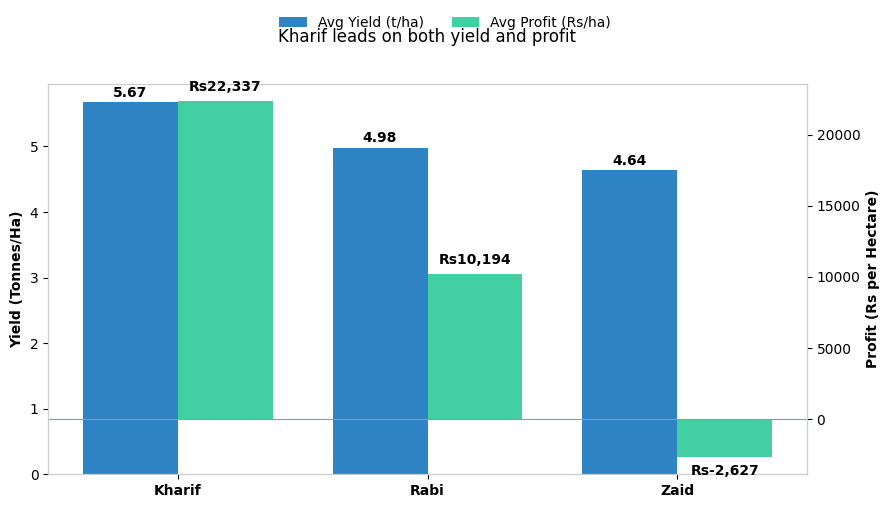

In [11]:
fig, ax1 = plt.subplots(figsize=(9, 5))
yield_m = df.groupby('Season')['Yield_Tonnes_Ha'].mean().reindex(SEASONS)
profit_m = df.groupby('Season')['Profit_per_Ha'].mean().reindex(SEASONS)

x = np.arange(len(SEASONS))
w = 0.38
bars1 = ax1.bar(x - w/2, yield_m, w, label='Avg Yield (t/ha)', color=BLUE_DARK)
ax1.set_ylabel('Yield (Tonnes/Ha)', fontweight='bold')
ax1.set_xticks(x); ax1.set_xticklabels(SEASONS, fontweight='bold')
for b in bars1:
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.08, f"{b.get_height():.2f}", ha='center', fontweight='bold')

ax2 = ax1.twinx()
bars2 = ax2.bar(x + w/2, profit_m, w, label='Avg Profit (Rs/ha)', color=TEAL)
ax2.set_ylabel('Profit (Rs per Hectare)', fontweight='bold')
ax2.axhline(0, color=GRAY, linewidth=0.8)
for b in bars2:
    va = 'bottom' if b.get_height()>=0 else 'top'
    off = 500 if b.get_height()>=0 else -500
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+off, f"Rs{b.get_height():,.0f}", ha='center', va=va, fontweight='bold')

fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=False)
plt.title('Kharif leads on both yield and profit', pad=30)
plt.tight_layout()
plt.savefig('images/chart1_yield_profit_season.png', dpi=150, bbox_inches='tight')
plt.show()


**Insight:** Kharif delivers the highest yield (5.64 t/ha) and by far the highest profit
(₹21,882/ha). Zaid actually runs at a small **loss** on average (-₹2,637/ha) despite having yield not
too far behind Kharif — this points to economics, not just production, driving the seasonal gap.

## 11. Result 2 — What Drives the Profit Decline?

Since yield alone doesn't explain the profit gap, we compare revenue and cost per hectare directly.

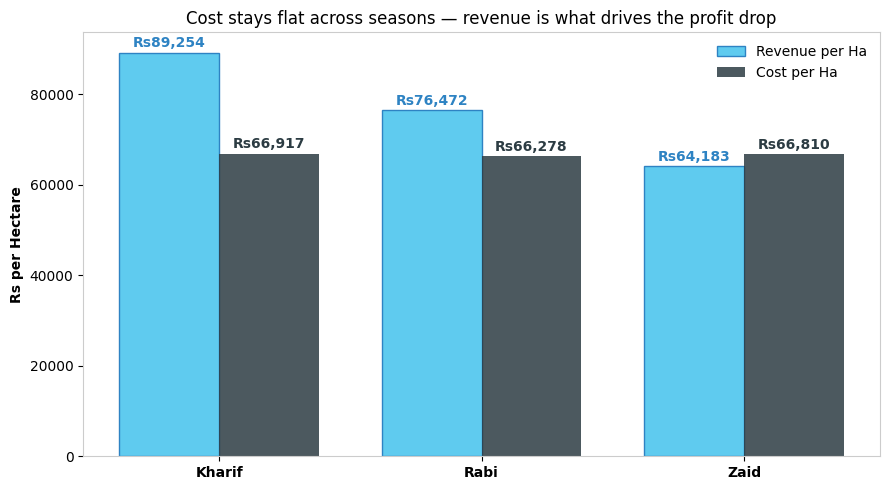

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
rev = df.groupby('Season')['Revenue_per_Ha'].mean().reindex(SEASONS)
cost = df.groupby('Season')['Cost_per_Ha'].mean().reindex(SEASONS)
x = np.arange(len(SEASONS)); w = 0.38
b1 = ax.bar(x-w/2, rev, w, label='Revenue per Ha', color=BLUE_LIGHT, edgecolor=BLUE_DARK)
b2 = ax.bar(x+w/2, cost, w, label='Cost per Ha', color=NAVY, alpha=0.85)
for b in b1:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+1200, f"Rs{b.get_height():,.0f}", ha='center', fontweight='bold', color=BLUE_DARK)
for b in b2:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+1200, f"Rs{b.get_height():,.0f}", ha='center', fontweight='bold', color=NAVY)
ax.set_xticks(x); ax.set_xticklabels(SEASONS, fontweight='bold')
ax.set_ylabel('Rs per Hectare', fontweight='bold')
ax.legend(frameon=False)
plt.title('Cost stays flat across seasons — revenue is what drives the profit drop')
plt.tight_layout()
plt.savefig('images/chart2_revenue_cost.png', dpi=150, bbox_inches='tight')
plt.show()


**Insight:** Cost per hectare barely moves across seasons (₹66,000–67,000 in all three). The
entire profit swing comes from the **revenue** side — Kharif revenue (₹88,783/ha) is ~38% higher than
Zaid (₹64,301/ha). Seasonal planning should focus on revenue-boosting factors (crop choice, market
timing), not just cost control.

## 12. Result 3 — Disease & Pest Risk vs Rainfall

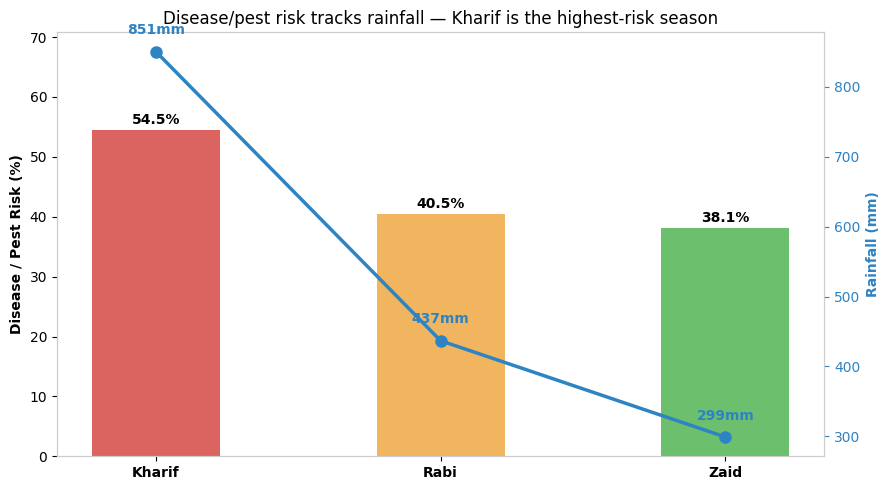

In [13]:
fig, ax1 = plt.subplots(figsize=(9, 5))
disease = df.groupby('Season')['Disease_Pest_Risk_pct'].mean().reindex(SEASONS)
rain = df.groupby('Season')['Rainfall_mm'].mean().reindex(SEASONS)
x = np.arange(len(SEASONS))
bars = ax1.bar(x, disease, 0.45, color=["#D9534F","#F0AD4E","#5CB85C"], alpha=0.9)
for b, v in zip(bars, disease):
    ax1.text(b.get_x()+b.get_width()/2, v+1, f"{v:.1f}%", ha='center', fontweight='bold')
ax1.set_ylabel('Disease / Pest Risk (%)', fontweight='bold')
ax1.set_xticks(x); ax1.set_xticklabels(SEASONS, fontweight='bold')
ax1.set_ylim(0, max(disease)*1.3)

ax2 = ax1.twinx()
ax2.plot(x, rain, color=BLUE_DARK, marker='o', linewidth=2.5, markersize=8)
for xi, v in zip(x, rain):
    ax2.text(xi, v+25, f"{v:.0f}mm", ha='center', color=BLUE_DARK, fontweight='bold')
ax2.set_ylabel('Rainfall (mm)', color=BLUE_DARK, fontweight='bold')
ax2.tick_params(axis='y', colors=BLUE_DARK)
plt.title('Disease/pest risk tracks rainfall — Kharif is the highest-risk season')
plt.tight_layout()
plt.savefig('images/chart3_disease_rainfall.png', dpi=150, bbox_inches='tight')
plt.show()


In [14]:
cols = ['Rainfall_mm','Humidity_pct','Soil_Moisture_pct','Disease_Pest_Risk_pct']
corr = df[cols].corr().round(2)
corr


,Rainfall_mm,Humidity_pct,Soil_Moisture_pct,Disease_Pest_Risk_pct
Rainfall_mm,1.00,0.52,0.52,0.63
Humidity_pct,0.52,1.00,0.45,0.54
Soil_Moisture_pct,0.52,0.45,1.00,0.38
Disease_Pest_Risk_pct,0.63,0.54,0.38,1.00


**Insight:** Kharif's disease/pest risk (54.5%) is nearly 1.5x higher than Zaid's (38.2%), and
it tracks closely with rainfall (r ≈ 0.63) and humidity (r ≈ 0.55). Wetter, more humid conditions
create a more favorable environment for pests and disease — this is a direct, explainable driver of
higher input costs (pesticide) in the wet season, even though Kharif remains the most profitable
season overall.

## 13. Result 4 — Water-Use Efficiency by Irrigation Method

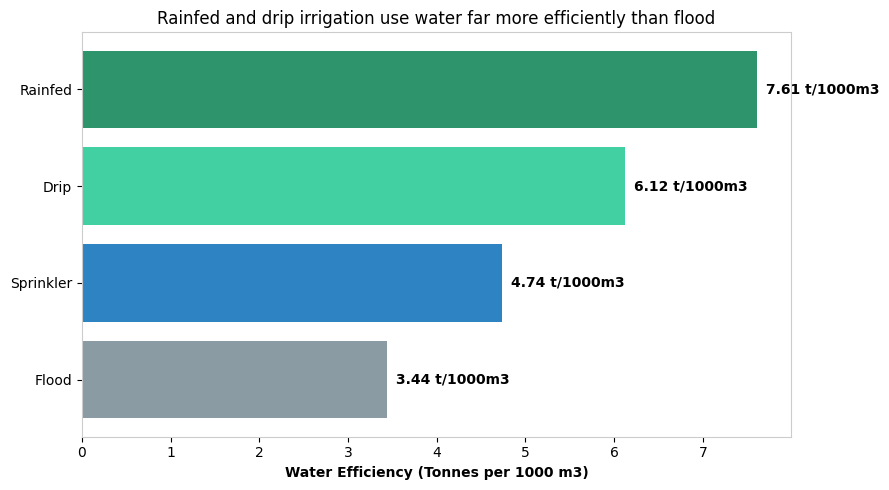

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
irr = df.groupby('Irrigation_Method')['Water_Efficiency_t_per_1000m3'].mean().sort_values(ascending=False)
colors_irr = [GREEN, TEAL, BLUE_DARK, GRAY]
bars = ax.barh(irr.index, irr.values, color=colors_irr)
for b, v in zip(bars, irr.values):
    ax.text(v+0.1, b.get_y()+b.get_height()/2, f"{v:.2f} t/1000m3", va='center', fontweight='bold')
ax.set_xlabel('Water Efficiency (Tonnes per 1000 m3)', fontweight='bold')
ax.invert_yaxis()
plt.title('Rainfed and drip irrigation use water far more efficiently than flood')
plt.tight_layout()
plt.savefig('images/chart4_water_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()


In [16]:
# Confirm irrigation method usage is roughly balanced across seasons
# (so the efficiency gap above isn't just a seasonal artifact)
pd.crosstab(df['Season'], df['Irrigation_Method'], normalize='index').round(2) * 100


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,23.0,33.0,26.0,18.0
Rabi,23.0,32.0,27.0,18.0
Zaid,24.0,32.0,24.0,21.0


**Insight:** Rainfed farming is the most water-efficient (7.56 t per 1000 m³), more than double
flood irrigation's efficiency (3.44 t per 1000 m³). Since irrigation methods are used in roughly the
same proportions across all three seasons, this is a genuine resource-efficiency gap, not a seasonal
coincidence — flood irrigation is a clear target for water-saving interventions.

## 14. Result 5 — Crop Profitability Across Seasons

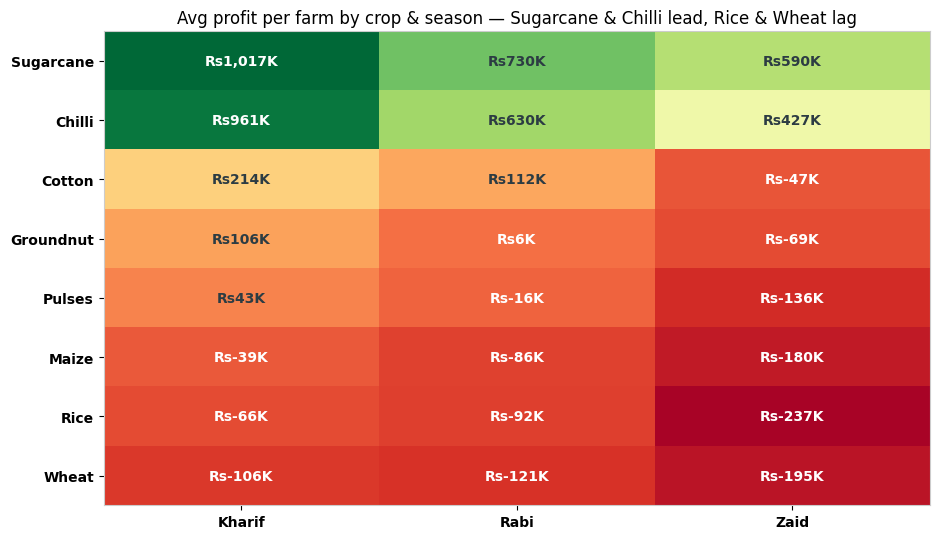

In [17]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))
pivot = df.pivot_table(index='Crop', columns='Season', values='Profit_INR', aggfunc='mean')[SEASONS]
pivot = pivot.sort_values('Kharif', ascending=False)

vmin, vmax = -250, 1000
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.get_cmap('RdYlGn')
im = ax.imshow(pivot.values/1000, cmap=cmap, norm=norm, aspect='auto')
ax.set_xticks(range(len(SEASONS))); ax.set_xticklabels(SEASONS, fontweight='bold')
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index, fontweight='bold')

def luminance(rgba):
    r, g, b = rgba[:3]
    return 0.299*r + 0.587*g + 0.114*b

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j] / 1000
        rgba = cmap(norm(val))
        color = 'white' if luminance(rgba) < 0.6 else NAVY
        ax.text(j, i, f"Rs{val:,.0f}K", ha='center', va='center', fontweight='bold', color=color)

plt.title('Avg profit per farm by crop & season — Sugarcane & Chilli lead, Rice & Wheat lag')
plt.tight_layout()
plt.savefig('images/chart5_crop_season_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


**Insight:** Sugarcane and Chilli are profitable in **every** season, while Rice, Wheat and Maize
post losses in most seasons regardless of timing. This tells us the biggest lever for a farmer's
profitability isn't which season they plant in — it's **which crop** they choose. Seasonal advisory
tools should weight crop choice at least as heavily as seasonal timing.

## 15. Summary of Key Findings

| # | Finding | Statistical support |
|---|---------|---------------------|
| 1 | Kharif has the highest yield and profit; Zaid runs at a slight loss on average | ANOVA on profit: p < 0.001 |
| 2 | Cost per hectare is nearly constant across seasons — the profit swing is driven by revenue, not cost | Descriptive comparison |
| 3 | Disease/pest risk is significantly higher in Kharif and tracks rainfall & humidity | ANOVA: p < 0.001; r ≈ 0.6 with rainfall |
| 4 | Rainfed and drip irrigation are far more water-efficient than flood irrigation | Descriptive comparison, balanced across seasons |
| 5 | Yield itself does **not** differ significantly by season — profit and risk do | ANOVA on yield: p ≈ 0.23 (not significant) |
| 6 | Crop choice (Sugarcane/Chilli vs Rice/Wheat/Maize) matters more than season for profitability | Crop x Season pivot |

## 16. Recommendations

- **Prioritize crop selection over season alone** — Sugarcane and Chilli remain profitable in every
  season; Rice, Wheat and Maize need cost restructuring or subsidy support regardless of season.
- **Budget for higher pest/disease management costs in Kharif** given the strong rainfall-risk link.
- **Encourage a shift from flood to drip/rainfed irrigation** where feasible, given the efficiency gap.
- **Focus revenue-side interventions (market access, pricing, crop insurance) on Zaid season**, since
  cost isn't the differentiator — revenue is.

## 17. Future Scope

- Build a machine-learning model to predict yield and profit from seasonal & environmental features
- Develop a crop-and-season recommendation engine tailored to local soil and weather conditions
- Integrate real-time weather and IoT soil-sensor feeds for dynamic seasonal advisories
- Extend coverage to more states and districts for finer-grained regional recommendations
- Feed seasonal risk scores into crop-insurance and agricultural lending decisions

---
*End of analysis.*
